### Step 1: Install necesscary packages

In [27]:
!pip install matplotlib
!pip install torch numpy transformers datasets tiktoken wandb tqdm

### Step 2: Package imports and configuration

In [28]:
import sys
import os
sys.path.append(os.path.abspath("..")) 
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import pickle
from model import GPT, GPTConfig
import random
from tqdm import tqdm
import time
import json
import matplotlib.pyplot as plt
# Configuration
beta = 0.5
device = 'cuda' if torch.cuda.is_available() else 'cpu'
base_lr = 1e-4
epochs = 5
batch_size = 64
max_length =64
num_samples = 1
max_new_tokens = 200
temperature = 0.8
top_k = 200
# tokenizer
with open("../sft/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi, itos = meta["stoi"], meta["itos"]
def encode(s): return [stoi[c] for c in s]
def decode(l): return ''.join([itos[i] for i in l])

# --- ADD THIS BLOCK ---
allowed_chars = set(stoi.keys())

def sanitize(s: str, *, replacement=""):  # replacement="" drops OOV chars
    # Keep only characters known to the tokenizer
    return ''.join((ch if ch in allowed_chars else replacement) for ch in s)

# Optional: quick OOV scan to see what's in your data
def find_oov_characters(pairs):
    oov = set()
    for p in pairs:
        for s in (p['negative'], p['positive']):
            for ch in s:
                if ch not in allowed_chars:
                    oov.add(ch)
    return oov
# ----------------------


### Step 3: Define helper functions

In [29]:
def compute_logprob(input_ids):
    inputs = input_ids[:, :-1]
    targets = input_ids[:, 1:]
    logits, _ = gpt(inputs, full_seq=True)
    B, T, V = logits.size()
    logits_flat = logits.reshape(-1, V)
    targets_flat = targets.reshape(-1)
    loss = F.cross_entropy(logits_flat, targets_flat, ignore_index=0, reduction='none')
    loss = loss.reshape(B, T)
    attention_mask = (targets != 0).float()
    loss = (loss * attention_mask).sum(dim=1) / attention_mask.sum(dim=1)
    return -loss 

def pad_or_truncate(seq, max_length):
    return seq[-max_length:] if len(seq) > max_length else seq + [0] * (max_length - len(seq))

def get_batches(lines, batch_size):
    random.shuffle(lines)
    #for l in lines:
    #    print(l[1])
    for i in range(0, len(lines), batch_size):
        batch = lines[i:i+batch_size]
        if len(batch) < batch_size:
            continue
        neg_inputs = [pad_or_truncate(encode(sanitize(p['negative']) + '\n\n\n\n'), max_length) for p in batch]
        pos_inputs = [pad_or_truncate(encode(sanitize(p['positive']) + '\n\n\n\n'), max_length) for p in batch]
        neg_tensor = torch.tensor(neg_inputs, dtype=torch.long, device=device)
        pos_tensor = torch.tensor(pos_inputs, dtype=torch.long, device=device)
        yield neg_tensor, pos_tensor

### Step 4: Load the pretrained NanoGPT model

In [30]:
ckpt = torch.load("../sft/gpt.pt", map_location=device)
gptconf = GPTConfig(**ckpt['model_args'])
gpt = GPT(gptconf)
state_dict = ckpt['model']
unwanted_prefix = '_orig_mod.'
for k in list(state_dict.keys()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
gpt.load_state_dict(state_dict)
gpt.to(device).train()

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(74, 348)
    (wpe): Embedding(256, 348)
    (drop): Dropout(p=0.2, inplace=False)
    (h): ModuleList(
      (0-5): 6 x Block(
        (ln_1): LayerNorm()
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=348, out_features=1044, bias=False)
          (c_proj): Linear(in_features=348, out_features=348, bias=False)
          (attn_dropout): Dropout(p=0.2, inplace=False)
          (resid_dropout): Dropout(p=0.2, inplace=False)
        )
        (ln_2): LayerNorm()
        (mlp): MLP(
          (c_fc): Linear(in_features=348, out_features=1392, bias=False)
          (gelu): GELU(approximate='none')
          (c_proj): Linear(in_features=1392, out_features=348, bias=False)
          (dropout): Dropout(p=0.2, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm()
  )
  (lm_head): Linear(in_features=348, out_features=74, bias=False)
)

### Step 5: Load Data (**students are required to complete this part!**)

In [31]:
# Load data from ./data/pos_neg_pairs.json
import json

with open("../dpo/pos_neg_pairs.json", "r") as f:
    lines = json.load(f)

### Step 6: Build the optimizer and scheduler (**students are required to complete this part!**)

In [32]:
# recommend to use the AdamW optimizer 

optimizer = torch.optim.AdamW(gpt.parameters(), lr=base_lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs * (len(lines) // batch_size), eta_min=1e-5)

### Step 7: Begin training (**students are required to complete this part!**)

Epoch 1/5 Loss: 0.0320 LR: 0.000091: : 3125it [48:31,  1.07it/s]


Epoch 1 Average loss: 0.0494
Saved checkpoint to ./dpo.pt


Epoch 2/5 Loss: 0.0285 LR: 0.000069: : 3125it [50:50,  1.02it/s]


Epoch 2 Average loss: 0.0304
Saved checkpoint to ./dpo.pt


Epoch 3/5 Loss: 0.0265 LR: 0.000041: : 3125it [50:09,  1.04it/s]


Epoch 3 Average loss: 0.0276
Saved checkpoint to ./dpo.pt


Epoch 4/5 Loss: 0.0257 LR: 0.000019: : 3125it [6:23:57,  7.37s/it]  


Epoch 4 Average loss: 0.0259
Saved checkpoint to ./dpo.pt


Epoch 5/5 Loss: 0.0253 LR: 0.000010: : 3125it [51:27,  1.01it/s]


Epoch 5 Average loss: 0.0251
Saved checkpoint to ./dpo.pt


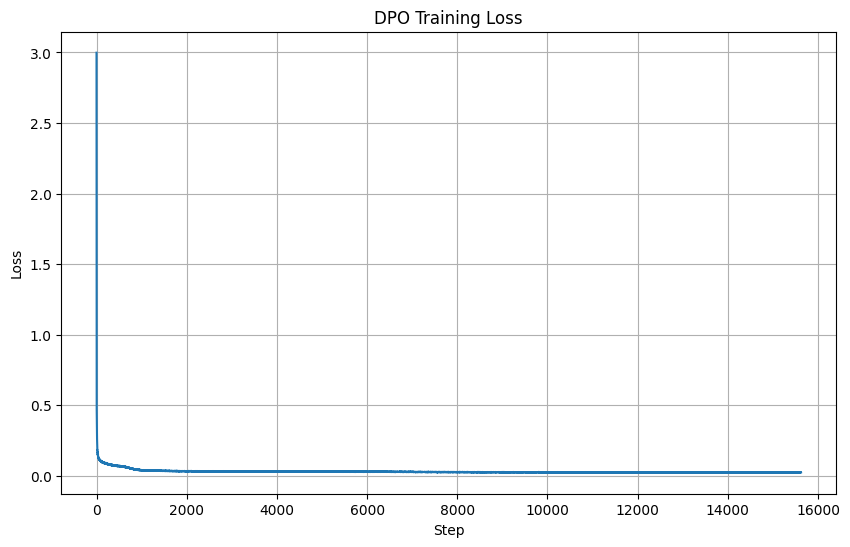

In [33]:
total_steps = len(lines) // batch_size
losses = []

for epoch in range(epochs):
    pbar = tqdm(get_batches(lines, batch_size))
    epoch_loss = 0
    for step, (neg_tensor,pos_tensor) in enumerate(pbar):
        optimizer.zero_grad()
        neg_logprob = compute_logprob(neg_tensor)
        pos_logprob = compute_logprob(pos_tensor)
        loss = -F.logsigmoid((pos_logprob - neg_logprob) / beta).mean() - pos_logprob.mean() * 0.1 
        
        loss.backward()
        # clip the gradient
        torch.nn.utils.clip_grad_norm_(gpt.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        # tracking loss
        epoch_loss += loss.item()
        losses.append(loss.item())
        
        pbar.set_description(f"Epoch {epoch+1}/{epochs} Loss: {loss.item():.4f} LR: {scheduler.get_last_lr()[0]:.6f}")
        
    print(f"Epoch {epoch+1} Average loss: {epoch_loss/total_steps:.4f}")
        
    ckpt_path = f"./dpo.pt"
    torch.save({
        "model_state_dict": gpt.state_dict(),
        "model_args": ckpt['model_args'],
    }, ckpt_path)
    print(f"Saved checkpoint to {ckpt_path}")
    
# we can also plot the loss
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('DPO Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

### Step 8: Begin testing (**students are required to complete this part!**)

In [35]:
# Load the fine-tuned model
ckpt_path = f"./dpo.pt"
checkpoint = torch.load(ckpt_path, map_location=device)
gptconf = GPTConfig(**checkpoint['model_args'])
gpt = GPT(gptconf).to(device)
try:
    state_dict = checkpoint['model']
except:
    state_dict = checkpoint['model_state_dict']
unwanted_prefix = '_orig_mod.'
for k,v in list(state_dict.items()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
gpt.load_state_dict(state_dict)
# Test
gpt.eval()
test_set = ["17+19=?", "3*17=?", "72/4=?", "72-x=34,x=?", "x*11=44,x=?", "3*17=?", "72/4=?", "72-x=34,x=?"]
with torch.no_grad():
    for prompt in test_set: 
        prompt_ids = encode(sanitize(prompt))
        x = torch.tensor([prompt_ids], dtype=torch.long, device=device)
        y = gpt.generate(x, max_new_tokens, temperature=temperature, top_k=top_k)

        # handle both returns: tuple (tokens, hidden) or just tokens
        tokens = y[0] if isinstance(y, tuple) else y          # [1, total_len]
        tokens_list = tokens[0].tolist()                       # [total_len]

        # decode only the generated continuation (not the prompt)
        prompt_ids = encode(sanitize(prompt))
        gen_only = tokens_list[len(prompt_ids):]               # slice off the prompt
        text = decode(gen_only)
        print(f"Prompt: {prompt}\nResponse: {text}\n{'='*40}")

        

Prompt: 17+19=?
Response:  The answer is 27 because 17+19 equals 27.
Prompt: 3*17=?
Response:  The answer is 41 because 3*17 equals 41.
Prompt: 72/4=?
Response:  The answer is 16 because 72/4 equals 16.
Prompt: 72-x=34,x=?
Response:  The answer is 22 because 72-3=34, so x=34//7=22.
Prompt: x*11=44,x=?
Response:  The answer is 4 because 6*4=44, so x=44//6=4.
Prompt: 3*17=?
Response:  The answer is 41 because 3*17 equals 41.
Prompt: 72/4=?
Response:  The answer is 21 because 72/4 equals 21.
Prompt: 72-x=34,x=?
Response:  The answer is 3 because 72-3=34, so x=-34//7=33.
